In [ ]:
# 사인함수 예측하기 p78

import math
import torch

x = torch.linspace(-math.pi, math.pi, 1000)
y = torch.sin(x)

# 3차 다항식 모델 표현

a = torch.randn(())  # randn : 정규분포를 따르는 size 크기 만큼의 랜덤값 반환 
b = torch.randn(())
c = torch.randn(())
d = torch.randn(())

# 모델
y_random = (a * x**3) + (b * x**2) + (c * x) + d
print( y_random )


tensor([-1.4297e+01, -1.4211e+01, -1.4125e+01, -1.4040e+01, -1.3955e+01,
        -1.3870e+01, -1.3786e+01, -1.3702e+01, -1.3618e+01, -1.3534e+01,
        -1.3451e+01, -1.3368e+01, -1.3286e+01, -1.3204e+01, -1.3122e+01,
        -1.3040e+01, -1.2959e+01, -1.2878e+01, -1.2798e+01, -1.2718e+01,
        -1.2638e+01, -1.2558e+01, -1.2479e+01, -1.2400e+01, -1.2321e+01,
        -1.2243e+01, -1.2165e+01, -1.2087e+01, -1.2009e+01, -1.1932e+01,
        -1.1855e+01, -1.1779e+01, -1.1703e+01, -1.1627e+01, -1.1551e+01,
        -1.1476e+01, -1.1401e+01, -1.1326e+01, -1.1252e+01, -1.1178e+01,
        -1.1104e+01, -1.1031e+01, -1.0958e+01, -1.0885e+01, -1.0812e+01,
        -1.0740e+01, -1.0668e+01, -1.0596e+01, -1.0525e+01, -1.0454e+01,
        -1.0383e+01, -1.0313e+01, -1.0243e+01, -1.0173e+01, -1.0103e+01,
        -1.0034e+01, -9.9651e+00, -9.8964e+00, -9.8280e+00, -9.7599e+00,
        -9.6921e+00, -9.6246e+00, -9.5574e+00, -9.4905e+00, -9.4239e+00,
        -9.3575e+00, -9.2915e+00, -9.2257e+00, -9.1

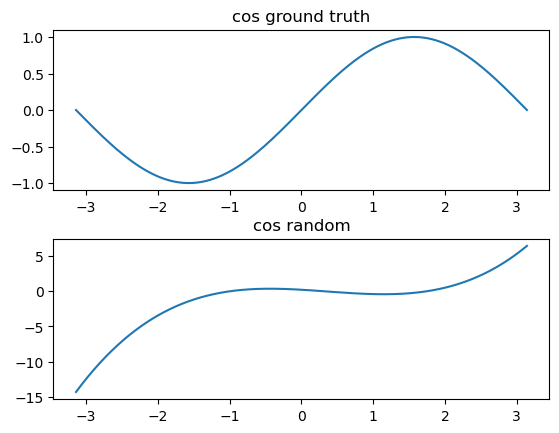

In [4]:
import matplotlib.pyplot as plt

plt.subplot(2,1,1)
plt.subplots_adjust(hspace=0.3)
plt.title("cos ground truth")
plt.plot(x, y)

plt.subplot(2,1,2)
plt.title("cos random")
plt.plot(x, y_random)

plt.show()

In [10]:
# 3차 다항식 모델 학습하기 p81

#하이퍼파라미터
learning_rate = 1e-6

# 데이터셋
x = torch.linspace(-math.pi, math.pi, 1000)
y = torch.sin(x)

# 모델 가중치 초기화
a = torch.randn(())  # randn : 정규분포를 따르는 size 크기 만큼의 랜덤값 반환 
b = torch.randn(())
c = torch.randn(())
d = torch.randn(())

for epoch in range(2000):
  # 순전파
  y_pred = (a * x**3) + (b * x**2) + (c *x) + d

  # 오차계산 MSE
  loss = (y_pred - y).pow(2).sum().item()

  # 백워드, 미분값(gradient) 계산
  grad_y_pred = 2.0 * (y_pred - y)
  grad_a = (grad_y_pred * x **3).sum()
  grad_b = (grad_y_pred * x **2).sum()
  grad_c = (grad_y_pred * x ).sum()
  grad_d = (grad_y_pred).sum()

  # 가중치 업데이트
  a -= learning_rate * grad_a
  b -= learning_rate * grad_b
  c -= learning_rate * grad_c
  d -= learning_rate * grad_d

# 출력

  if epoch % 100 ==0:
    print("epoch: ", epoch, "loss: ", loss)

epoch:  0 loss:  37702.5
epoch:  100 loss:  159.14637756347656
epoch:  200 loss:  132.88082885742188
epoch:  300 loss:  111.23246765136719
epoch:  400 loss:  93.25579833984375
epoch:  500 loss:  78.32388305664062
epoch:  600 loss:  65.91770935058594
epoch:  700 loss:  55.60722732543945
epoch:  800 loss:  47.0361442565918
epoch:  900 loss:  39.90913772583008
epoch:  1000 loss:  33.98139572143555
epoch:  1100 loss:  29.04983901977539
epoch:  1200 loss:  24.946016311645508
epoch:  1300 loss:  21.530101776123047
epoch:  1400 loss:  18.686113357543945
epoch:  1500 loss:  16.317699432373047
epoch:  1600 loss:  14.344861030578613
epoch:  1700 loss:  12.701152801513672
epoch:  1800 loss:  11.33129596710205
epoch:  1900 loss:  10.18944263458252


In [11]:
# 학습된 가중치 확인
print( a, b, c, d)


tensor(-0.0868) tensor(0.0158) tensor(0.8113) tensor(-0.0916)


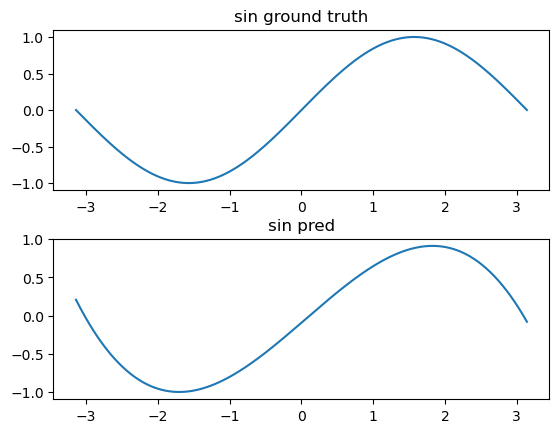

In [14]:
# 예측값을 sin 그래프로 표현하기

plt.subplot(2, 1, 1)
plt.subplots_adjust(hspace=0.3)
plt.title('sin ground truth')
plt.plot(x, y)

plt.subplot(2, 1, 2)
plt.title('sin pred')
plt.plot(x, y_pred)

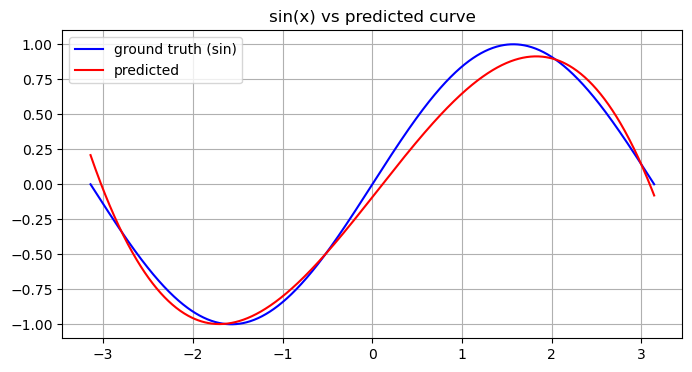

In [15]:
# 하나의 차트로 비교해서 보기

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))  # 그림 사이즈 조정
plt.title('sin(x) vs predicted curve')

# 실제 sin 곡선 (파란색)
plt.plot(x, y, label='ground truth (sin)', color='blue')

# 모델 예측 곡선 (빨간색)
plt.plot(x, y_pred, label='predicted', color='red')

plt.legend()  # 범례 표시
plt.grid(True)
plt.show()


In [16]:
# 자동 미분 auto-grad p84

# 하이퍼파라미터
learning_rate = 1e-6

# 데이터셋
x = torch.linspace(-math.pi, math.pi, 1000)
y = torch.sin(x)

# 모델 가중치 초기화
a = torch.tensor(torch.randn(()), requires_grad=True)
b = torch.tensor(torch.randn(()), requires_grad=True)
c = torch.tensor(torch.randn(()), requires_grad=True)
d = torch.tensor(torch.randn(()), requires_grad=True)

for epoch in range(2000):
  # 순전파
  y_pred = (a * x**3) + (b * x**2) + (c * x) + d

  # 오차 계산 (MSE)
  loss = (y_pred - y).pow(2).sum()

  # 백워드
  loss.backward()

  # 가중치 업데이트
  with torch.no_grad():
    a -= learning_rate * a.grad
    b -= learning_rate * b.grad
    c -= learning_rate * c.grad
    d -= learning_rate * d.grad

    a.grad = None
    b.grad = None
    c.grad = None
    d.grad = None

  # 출력
  if epoch % 100 == 0:
    print("epoch: ", epoch, "loss: ", loss.item())

C:\Users\pc04-06\AppData\Local\Temp\ipykernel_16216\2896378586.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a = torch.tensor(torch.randn(()), requires_grad=True)
C:\Users\pc04-06\AppData\Local\Temp\ipykernel_16216\2896378586.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(torch.randn(()), requires_grad=True)
C:\Users\pc04-06\AppData\Local\Temp\ipykernel_16216\2896378586.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c = torch.tensor(torch.randn(()), requires_grad=True)
C:\Users\pc04-06\AppData\Local\Tem

epoch:  0 loss:  77232.78125
epoch:  100 loss:  757.7290649414062
epoch:  200 loss:  624.9959716796875
epoch:  300 loss:  526.4932250976562
epoch:  400 loss:  443.6293029785156
epoch:  500 loss:  373.91754150390625
epoch:  600 loss:  315.2707824707031
epoch:  700 loss:  265.9324035644531
epoch:  800 loss:  224.42547607421875
epoch:  900 loss:  189.50656127929688
epoch:  1000 loss:  160.1300506591797
epoch:  1100 loss:  135.4162139892578
epoch:  1200 loss:  114.6252212524414
epoch:  1300 loss:  97.13417053222656
epoch:  1400 loss:  82.41940307617188
epoch:  1500 loss:  70.04017639160156
epoch:  1600 loss:  59.62586212158203
epoch:  1700 loss:  50.86454772949219
epoch:  1800 loss:  43.493858337402344
epoch:  1900 loss:  37.293067932128906


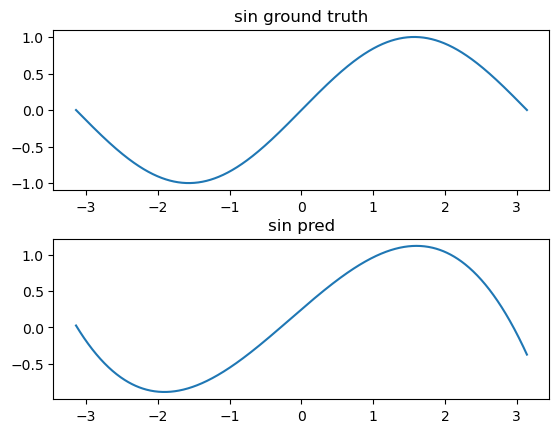

In [17]:
y_pred = y_pred.detach().numpy()

plt.subplot(2,1,1)
plt.subplots_adjust(hspace=0.3)
plt.title("sin ground truth")
plt.plot(x,y)

plt.subplot(2,1,2)
plt.title("sin pred")
plt.plot(x, y_pred)

In [20]:
# 1.5 파이토치 모듈 사용하기

#파이토치는 모델을 nn.Module을 상속받는 클래스 형태로 정의하여 사용하는 스타일을 
# 권장하고 있어 앞서 사용한 3차 다항식모델을 nn.Module을 이용한 모델로 만들어 봄

import torch.nn as nn 


class LegendrePolynomial3(nn.Module):
  def __init__(self):
    super().__init__()

    self.a = nn.Parameter(torch.randn(()))
    self.b = nn.Parameter(torch.randn(()))
    self.c = nn.Parameter(torch.randn(()))
    self.d = nn.Parameter(torch.randn(()))

  def forward(self, x):
    return(self.a * x **3) + (self.b * x **2) + (self.c * x) + self.d 

learning_rate = 1e-6

x = torch.linspace(-math.pi, math.pi, 1000)
y = torch.sin(x)

model = LegendrePolynomial3()

for epoch in range(2000):

  y_pred = model(x)
  loss = nn.MSELoss(reduction='sum')(y_pred, y)

  loss.backward()

  with torch.no_grad():
    model.a -= learning_rate * model.a.grad
    model.b -= learning_rate * model.b.grad
    model.c -= learning_rate * model.c.grad
    model.d -= learning_rate * model.d.grad

    model.a.grad = None
    model.b.grad = None
    model.c.grad = None
    model.d.grad = None

    if epoch % 100 == 0:
      print("epoch: ", epoch, "loss: ", loss.item())


epoch:  0 loss:  19813.46484375
epoch:  100 loss:  2257.18603515625
epoch:  200 loss:  1892.3402099609375
epoch:  300 loss:  1589.77490234375
epoch:  400 loss:  1335.7791748046875
epoch:  500 loss:  1122.5404052734375
epoch:  600 loss:  943.5062866210938
epoch:  700 loss:  793.1813354492188
epoch:  800 loss:  666.9539794921875
epoch:  900 loss:  560.95458984375
epoch:  1000 loss:  471.9373474121094
epoch:  1100 loss:  397.1771545410156
epoch:  1200 loss:  334.3870849609375
epoch:  1300 loss:  281.6474304199219
epoch:  1400 loss:  237.347412109375
epoch:  1500 loss:  200.13479614257812
epoch:  1600 loss:  168.87403869628906
epoch:  1700 loss:  142.612060546875
epoch:  1800 loss:  120.54841613769531
epoch:  1900 loss:  102.01116943359375


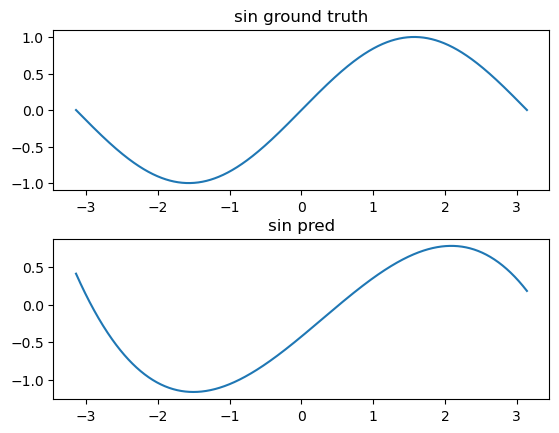

In [21]:
x = x.squeeze()
y_pred = model(x).clone().detach().squeeze().numpy()
y = y.squeeze()

plt.subplot(2,1,1)
plt.subplots_adjust(hspace=0.3)
plt.title('sin ground truth')
plt.plot(x, y)

plt.subplot(2,1,2)
plt.title('sin pred')
plt.plot(x, y_pred)

In [22]:
# 최적화 함수 p91

# 하이퍼파라미터
learning_rate = 1e-6

# 데이터셋
x = torch.linspace(-math.pi, math.pi, 1000)
y = torch.sin(x)

# 모델 초기화
model = LegendrePolynomial3()

criterion = nn.MSELoss(reduction='sum')

print(list(model.parameters()))
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

for epoch in range(2000):
  # 미분값 초기화
  optimizer.zero_grad()

  # 순전파
  y_pred = model(x)

  # 오차 계산
  loss = criterion(y_pred, y)

  # 백워드
  loss.backward()

  # 가중치 업데이트
  optimizer.step()

  # 출력
  if epoch % 100 == 0:
    print("epoch: ", epoch, "loss: ", loss.item())

[Parameter containing:
tensor(1.2262, requires_grad=True), Parameter containing:
tensor(-1.9410, requires_grad=True), Parameter containing:
tensor(-0.0198, requires_grad=True), Parameter containing:
tensor(-1.3811, requires_grad=True)]
epoch:  0 loss:  291135.71875
epoch:  100 loss:  882.2823486328125
epoch:  200 loss:  708.73876953125
epoch:  300 loss:  586.25439453125
epoch:  400 loss:  485.2145690917969
epoch:  500 loss:  401.8363342285156
epoch:  600 loss:  333.01300048828125
epoch:  700 loss:  276.1875305175781
epoch:  800 loss:  229.2545166015625
epoch:  900 loss:  190.48085021972656
epoch:  1000 loss:  158.438720703125
epoch:  1100 loss:  131.9517059326172
epoch:  1200 loss:  110.05049133300781
epoch:  1300 loss:  91.93574523925781
epoch:  1400 loss:  76.94863891601562
epoch:  1500 loss:  64.54541015625
epoch:  1600 loss:  54.277652740478516
epoch:  1700 loss:  45.77526092529297
epoch:  1800 loss:  38.732704162597656
epoch:  1900 loss:  32.89756774902344


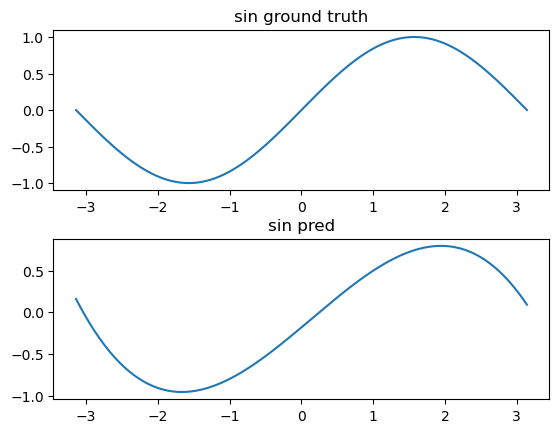

In [23]:
x = x.squeeze()
y_pred = model(x).clone().detach().squeeze().numpy()
y = y.squeeze()

plt.subplot(2,1,1)
plt.subplots_adjust(hspace=0.3)
plt.title("sin ground truth")
plt.plot(x,y)

plt.subplot(2,1,2)
plt.title("sin pred")
plt.plot(x, y_pred)